In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential # Sequential model which is used to make neural networks
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D    #Conv2d extracts features
from tensorflow.keras.layers import MaxPooling2D #Pooling for reducing size
from tensorflow.keras.layers import Flatten    #Flatten reshapes
from tensorflow.keras.layers import Dropout    # Dropout prevents overfitting
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')



In [95]:
df = pd.read_csv('mnist_train.csv')
df_test = pd.read_csv('mnist_test.csv')

# Fill NaN values with 0, assuming missing pixel data should be black
df = df.fillna(0)
df_test = df_test.fillna(0)

In [96]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [97]:
df.shape

(60000, 785)

In [98]:
df['10x16'].value_counts().sort_index()

,count
10x16,
0,25615
1,68
2,120
3,134
4,143
...,...
251,341
252,2009
253,5877


In [99]:
df.isnull().sum()

,0
label,0
1x1,0
1x2,0
1x3,0
1x4,0
...,...
28x24,0
28x25,0
28x26,0
28x27,0


In [100]:
# Pre processing
X_train = df.drop('label',axis = 1).values
y_train = df['label'].values
X_test = df_test.drop('label',axis= 1).values
y_test = df_test['label'].values

In [101]:
X_train = X_train.astype("float32")/255.0
X_test = X_test.astype("float32")/255.0

In [102]:
X_train_img = X_train.reshape(-1,28,28)
X_test_img = X_test.reshape(-1,28,28)

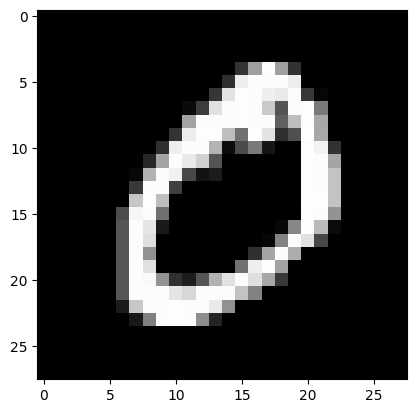

In [103]:
plt.imshow(X_train_img[1], cmap='gray')

In [104]:
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

In [105]:
perceptron_model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10,activation='softmax')
])

In [106]:
perceptron_model.compile(loss= "categorical_crossentropy",optimizer= "sgd", metrics= ['accuracy'])

In [107]:
perceptron_history = perceptron_model.fit(
  X_train_img, y_train_cat, batch_size = 32, epochs = 5,
  verbose = 1,validation_data = (X_test_img,y_test_cat))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8191 - loss: 0.7707 - val_accuracy: 0.8820 - val_loss: 0.4774
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8809 - loss: 0.4540 - val_accuracy: 0.8955 - val_loss: 0.3987
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8916 - loss: 0.4019 - val_accuracy: 0.9019 - val_loss: 0.3679
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8974 - loss: 0.3759 - val_accuracy: 0.9060 - val_loss: 0.3473
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9011 - loss: 0.3593 - val_accuracy: 0.9091 - val_loss: 0.3360


In [108]:
perceptron_model_acc = perceptron_model.evaluate(X_test_img,y_test_cat,verbose = 0)[1]

In [109]:
perceptron_model_acc

0.9090999960899353

In [110]:
# ANN MODEL
ann_model = Sequential([
    Flatten(input_shape = (28,28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

In [111]:
ann_model.compile(loss="categorical_crossentropy",optimizer='adam',metrics=['accuracy'])

In [114]:
history_ann = ann_model.fit(
    X_train_img,y_train_cat, validation_data =(X_test_img,y_test_cat),
    epochs = 5, batch_size = 32,verbose = 1
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9297 - loss: 0.2378 - val_accuracy: 0.9630 - val_loss: 0.1196
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9709 - loss: 0.0973 - val_accuracy: 0.9743 - val_loss: 0.0845
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9785 - loss: 0.0686 - val_accuracy: 0.9745 - val_loss: 0.0844
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9829 - loss: 0.0526 - val_accuracy: 0.9774 - val_loss: 0.0710
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9866 - loss: 0.0409 - val_accuracy: 0.9743 - val_loss: 0.0846


In [116]:
ann_model_acc = ann_model.evaluate(X_test_img,y_test_cat,verbose = 0)[1]

In [117]:
ann_model_acc

0.9743000268936157

In [118]:
X_train_img_cnn = X_train.reshape(-1,28,28,1)
X_test_img_cnn = X_test.reshape(-1,28,28,1)

In [119]:
# CNN MODEL
cnn_model = Sequential([
    Conv2D(filters= 32,kernel_size=(3,3),input_shape = (28,28,1),activation= "relu"), # Convolution Layer
    MaxPooling2D(pool_size=(2,2)),# Pooling Layer
    Conv2D(filters= 64,kernel_size=(3,3),activation= "relu"), # Convolution Layer
    MaxPooling2D(pool_size=(2,2)),# Pooling Layer
    Flatten(),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dropout(0.5),
    Dense(10,activation="softmax")

])

In [120]:
cnn_model.compile(loss= "categorical_crossentropy",optimizer= "adam",metrics=['accuracy'])

In [121]:
history_cnn = cnn_model.fit(
    X_train_img_cnn,y_train_cat,validation_data = (X_test_img_cnn,y_test_cat),
    epochs = 5, batch_size = 32,verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 29ms/step - accuracy: 0.9281 - loss: 0.2387 - val_accuracy: 0.9818 - val_loss: 0.0565
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 30ms/step - accuracy: 0.9802 - loss: 0.0753 - val_accuracy: 0.9883 - val_loss: 0.0363
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.9857 - loss: 0.0532 - val_accuracy: 0.9887 - val_loss: 0.0381
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 35ms/step - accuracy: 0.9895 - loss: 0.0407 - val_accuracy: 0.9922 - val_loss: 0.0259
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 30ms/step - accuracy: 0.9917 - loss: 0.0299 - val_accuracy: 0.9921 - val_loss: 0.0297


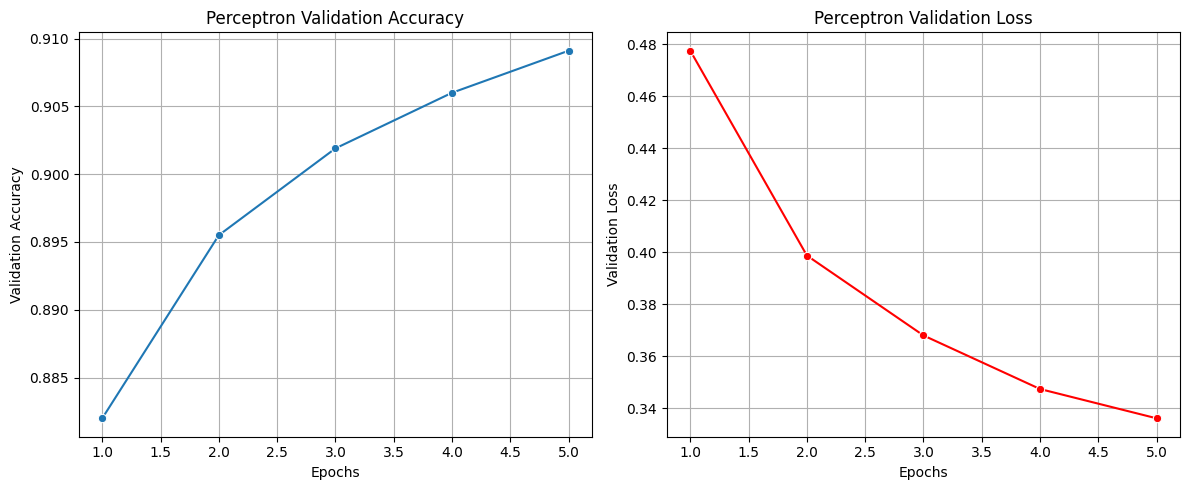

In [122]:


# Get training history for perceptron
history_dict = perceptron_history.history
val_acc = history_dict['val_accuracy']
val_loss = history_dict['val_loss']
epochs = range(1, len(val_acc) + 1)

plt.figure(figsize=(12, 5))

# Plot Validation Accuracy
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.lineplot(x=epochs, y=val_acc, marker='o')
plt.title('Perceptron Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.grid(True)

# Plot Validation Loss
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.lineplot(x=epochs, y=val_loss, marker='o', color='red')
plt.title('Perceptron Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.grid(True)

plt.tight_layout()
plt.show()

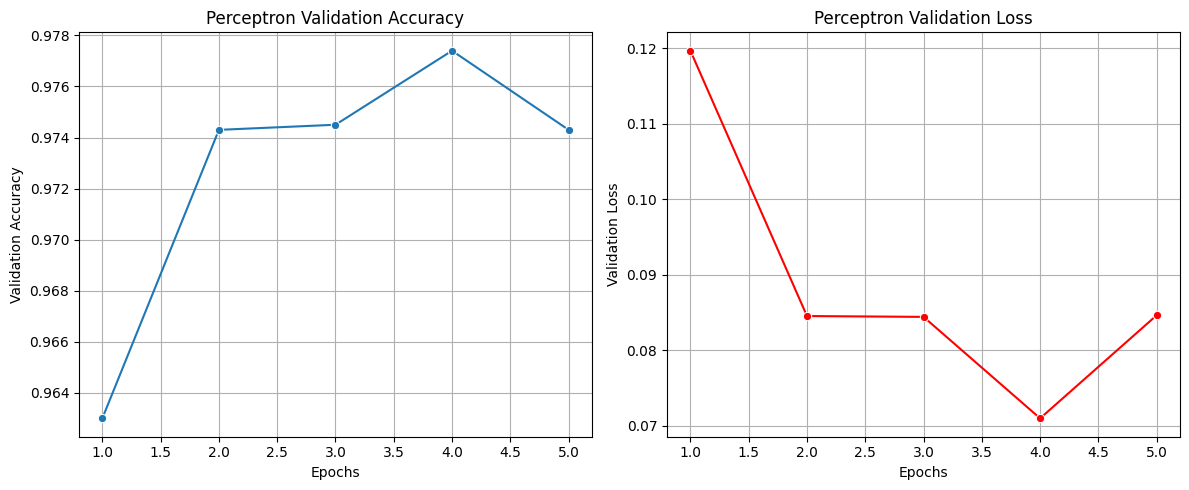

In [127]:
# Get training history for ANN
history_dict_ann = history_ann.history
val_acc = history_dict_ann['val_accuracy']
val_loss = history_dict_ann['val_loss']
epochs = range(1, len(val_acc) + 1)

plt.figure(figsize=(12, 5))

# Plot Validation Accuracy
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.lineplot(x=epochs, y=val_acc, marker='o')
plt.title('Perceptron Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.grid(True)

# Plot Validation Loss
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.lineplot(x=epochs, y=val_loss, marker='o', color='red')
plt.title('Perceptron Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.grid(True)

plt.tight_layout()
plt.show()

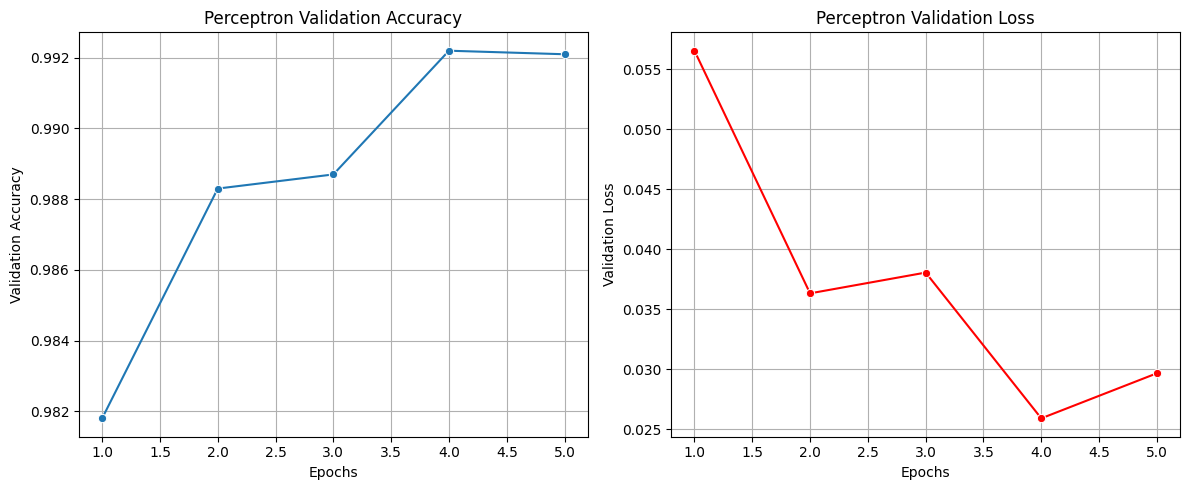

In [128]:
# Get training history for perceptron
history_dict_cnn = history_cnn.history
val_acc = history_dict_cnn['val_accuracy']
val_loss = history_dict_cnn['val_loss']
epochs = range(1, len(val_acc) + 1)

plt.figure(figsize=(12, 5))

# Plot Validation Accuracy
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.lineplot(x=epochs, y=val_acc, marker='o')
plt.title('Perceptron Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.grid(True)

# Plot Validation Loss
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.lineplot(x=epochs, y=val_loss, marker='o', color='red')
plt.title('Perceptron Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.grid(True)

plt.tight_layout()
plt.show()

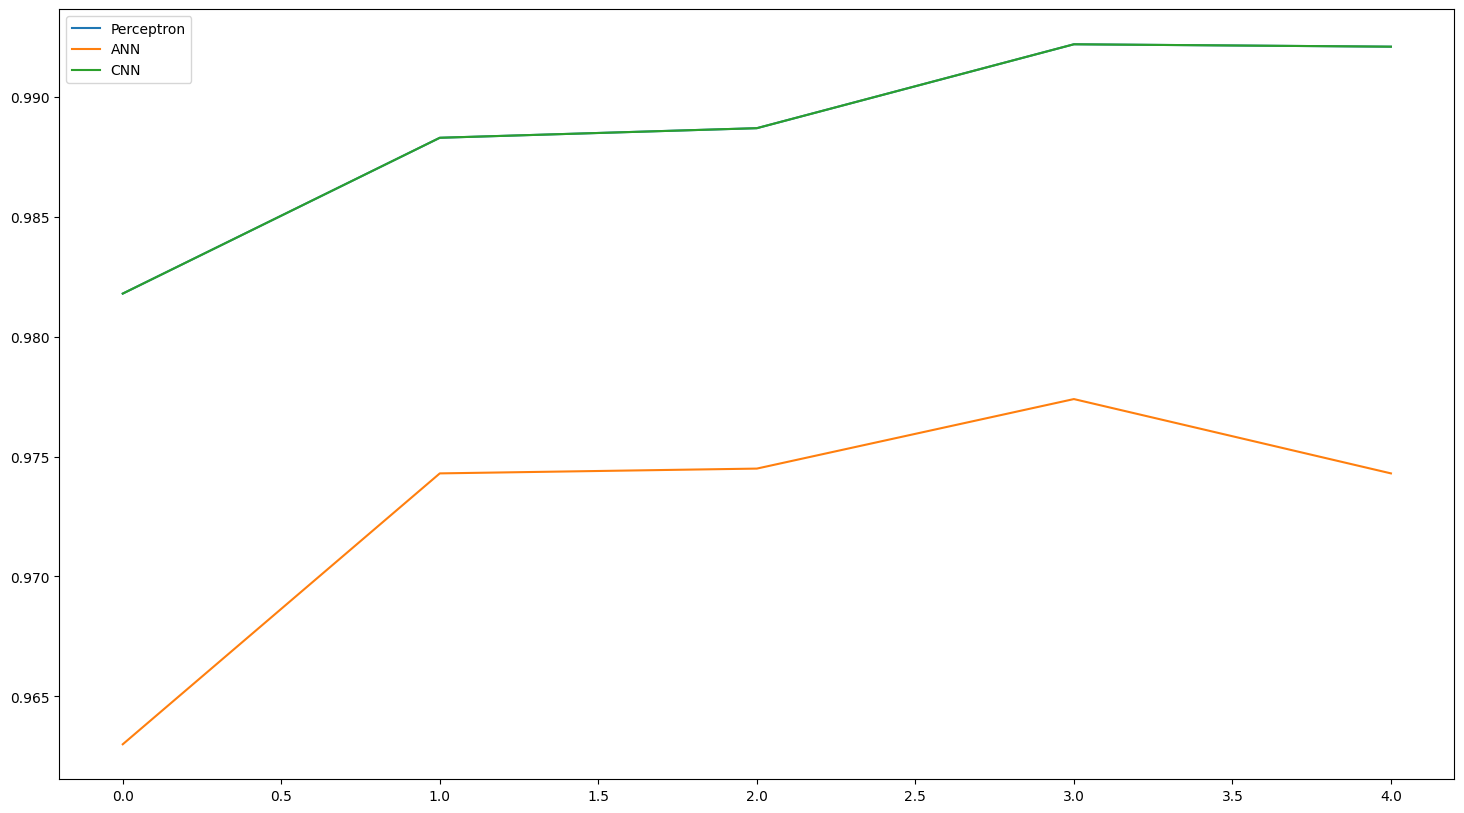

In [134]:
plt.figure(figsize= (18,10))
plt.plot(history_dict['val_accuracy'], label= "Perceptron")
plt.plot(history_dict_ann['val_accuracy'], label= "ANN")
plt.plot(history_dict_cnn['val_accuracy'], label= "CNN")
plt.legend()

plt.show()

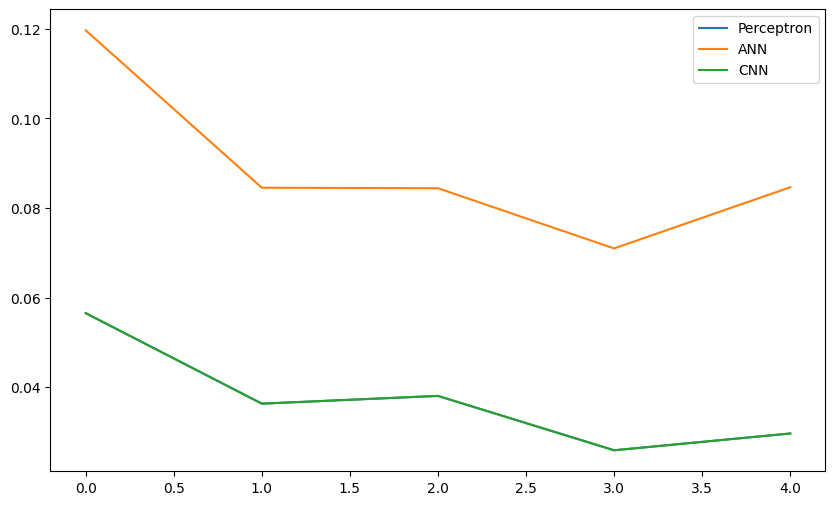

In [137]:
plt.figure(figsize= (10,6))
plt.plot(history_dict['val_loss'], label= "Perceptron")
plt.plot(history_dict_ann['val_loss'], label= "ANN")
plt.plot(history_dict_cnn['val_loss'], label= "CNN")
plt.legend()

plt.show()

In [138]:
cnn_model.save('mnist_cnn_model.h5')

In [139]:
from google.colab import files
files.download('mnist_cnn_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>